In [1]:
import pandas as pd
import numpy as np
import simplejson
import torch
import lightning as L
from Utils import get_tt_split

In [4]:
ln_data = pd.read_excel('../data/lymph_node_data.xlsx')
ln_data.head()

,Dummy ID,ROI,Age at Diagnosis (Calculated),Pathological Grade,Gender,Race,Therapeutic combination,Tm Laterality (R/L),Tumor subsite (BOT/Tonsil/Soft Palate/Pharyngeal wall/GPS/NOS),HPV/P16 status,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
0,10001,GTVp1,54.394444,II,Male,White/Caucasion,Radiation alone,L,Tonsil,Unknown,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
1,10184,NaN,63.130556,II,Male,White/Caucasion,CC,L,Tonsil,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10009,GTVp1,55.447222,III,Female,White/Caucasion,Radiation alone,R,Tonsil,Unknown,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
3,10010,NaN,73.050000,III,Male,White/Caucasion,Radiation alone,Bilateral,NOS,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10069,GTVp1,60.525000,NaN,Male,White/Caucasion,IC+Radiation alone,L,Tonsil,Unknown,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [293]:
ln_data = ln_data.rename({'Dummy ID': 'id'},axis=1).set_index('id')
ln_data.head()

KeyError: "None of ['id'] are in the columns"

In [294]:
radiomic_cols = [c for c in ln_data.columns if c[0] == 'F' and '-' in c]
rm = ln_data[radiomic_cols].fillna(0)
rm.head()

,F2-GrayLevelCooccurenceMatrix2590-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-6ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-7ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-1ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-2ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-3ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-6ClusterTendendcy,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
ID,,,,,,,,,,,,,,,,,,,,,
10001,2169.381070,2004.708495,1858.470787,1734.634735,1996.668300,1542.119170,1419.922264,1420.754836,1433.812698,1410.230095,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
10184,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10009,2503.705527,2258.113520,1995.820593,1703.374488,2308.163473,1649.224538,1586.523120,1631.963532,1660.486979,1709.550840,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
10010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10069,957.125333,849.701668,794.556584,739.654003,1127.261727,864.073903,820.264055,835.117929,840.909730,837.959249,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [498]:
train_ids, test_ids = get_tt_split()
train_ids = [c for c in rm.index.values if c not in test_ids]
rm.loc[train_ids].shape,rm.loc[test_ids].shape

((497, 3367), (147, 3367))

In [630]:

class Encoder(torch.nn.Module):
    def __init__(self,
                 input_shape,
                 embedding_size = 5,
                 hidden_dims = [1000,1000],
                 input_dropout = .1,
                 pre_embedding_dropout = 0,
                 activation = torch.nn.ReLU,
                ):
        super().__init__()
        modules = []
        self.input_dropout = torch.nn.Dropout(input_dropout)
        currdim = input_shape
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_layer_mean = torch.nn.Linear(currdim,embedding_size)
        self.embedding_layer_std = torch.nn.Linear(currdim,embedding_size)
        self.pre_embedding_dropout = torch.nn.Dropout(pre_embedding_dropout)
        

    def forward(self, x):
        x = self.input_dropout(x)
        x = self.hidden_layers(x)
        x = self.pre_embedding_dropout(x)
        mu = self.embedding_layer_mean(x)
        logvar = self.embedding_layer_std(x)
        
        return mu,logvar

class Decoder(torch.nn.Module):
    def __init__(self,
                 output_shape,
                 embedding_size = 5,
                 hidden_dims = [1000,1000],
                 penultimate_dropout = .1,
                 embedding_dropout = 0,
                 activation = None,
                ):
        super().__init__()
        modules = []
        currdim = embedding_size
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_dropout = torch.nn.Dropout(embedding_dropout)
        self.penultimate_dropout = torch.nn.Dropout(penultimate_dropout)
        self.output_layer = torch.nn.Linear(currdim,output_shape)
        
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) from
        N(0,1).
        :param mu: (Tensor) Mean of the latent Gaussian [B x D]
        :param logvar: (Tensor) Standard deviation of the latent Gaussian [B x D]
        :return: (Tensor) [B x D]
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu
    
        
    def final_transform(self,x):
        #for subclass options
        return x

    def forward(self, xmu,xlogvar):
        x = self.reparameterize(xmu,xlogvar)
        x = self.embedding_dropout(x)
        x = self.hidden_layers(x)
        x = self.penultimate_dropout(x)
        x = self.output_layer(x)
        return self.final_transform(x)
    
class RadiomicsVAE(L.LightningModule):
    def __init__(self, input_shape, embedding_size,encoder_args={},decoder_args={},kld_weight=.01,mse_weight=1,lr=.001):
        self.lr=lr
        super().__init__()
        self.encoder = Encoder(input_shape,embedding_size=embedding_size,**encoder_args)
        self.decoder = Decoder(input_shape,embedding_size=embedding_size,**decoder_args)
        self.kld_weight = kld_weight
        self.mse_weight = mse_weight
        

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        
        return self.mse_weight*mse_loss + self.kld_weight*kld_loss
    
    def validation_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        self.log('val_kld_loss',kld_loss)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        self.log("val_mse_loss",mse_loss)
        val_loss = self.mse_weight*mse_loss + self.kld_weight*kld_loss
        self.log("val_loss",val_loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer
    
model = RadiomicsVAE(x.shape[1],10,lr=.000001,kld_weight=0.1)
model

RadiomicsVAE(
  (encoder): Encoder(
    (input_dropout): Dropout(p=0.1, inplace=False)
    (hidden_layers): Sequential(
      (0): Linear(in_features=3367, out_features=1000, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1000, out_features=1000, bias=True)
      (3): ReLU()
    )
    (embedding_layer_mean): Linear(in_features=1000, out_features=10, bias=True)
    (embedding_layer_std): Linear(in_features=1000, out_features=10, bias=True)
    (pre_embedding_dropout): Dropout(p=0, inplace=False)
  )
  (decoder): Decoder(
    (hidden_layers): Sequential(
      (0): Linear(in_features=10, out_features=1000, bias=True)
      (1): Linear(in_features=1000, out_features=1000, bias=True)
    )
    (embedding_dropout): Dropout(p=0, inplace=False)
    (penultimate_dropout): Dropout(p=0.1, inplace=False)
    (output_layer): Linear(in_features=1000, out_features=3367, bias=True)
  )
)

In [631]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

BATCHSIZE = 5
[xtrain,xval] = [torch.from_numpy(rm.loc[ids].values.astype('float')).type(torch.float32) for ids in [train_ids,test_ids]]
normalize = lambda xx: (xx - xtrain.mean(axis=0))/(xtrain.std(axis=0) + .1)
convert = lambda x: torch.utils.data.DataLoader(normalize(x),batch_size=BATCHSIZE)
es = EarlyStopping(monitor='val_loss',mode='min',patience=200)
trainer = L.Trainer(max_epochs=10000,callbacks=[es])
torch.set_float32_matmul_precision('medium')
trainer.fit(model,convert(xtrain),convert(xval))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | encoder | Encoder | 4.4 M  | train
1 | decoder | Decoder | 4.4 M  | train
--------------------------------------------
8.8 M     Trainable params
0         Non-trainable params
8.8 M     Total params
35.086    Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [632]:
xall = torch.concat([xtrain,xval],axis=0)
trainer.validate(model,convert(xall))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |                                             | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_kld_loss          1.1703784465789795
        val_loss            0.4016120433807373
      val_mse_loss          0.28457415103912354
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_kld_loss': 1.1703784465789795,
  'val_mse_loss': 0.28457415103912354,
  'val_loss': 0.4016120433807373}]

In [633]:
with torch.no_grad():
    embedding = model.decoder.reparameterize(*model.encoder(normalize(torch.from_numpy(rm.values.astype(np.float32))))).detach().cpu().numpy()
embedding

array([[-2.5724535 , -0.75866276,  0.52652305, ...,  0.7254442 ,
        -2.5822082 ,  0.9352763 ],
       [-0.45934474,  2.2479892 ,  0.03731598, ...,  0.20829535,
         0.03441143, -0.7916398 ],
       [-0.7918231 , -0.17159176,  0.8051404 , ..., -0.27661484,
        -0.42088106,  0.5196911 ],
       ...,
       [-0.877226  , -0.39967978,  0.51714385, ...,  0.31917882,
        -1.4787695 ,  0.23672983],
       [-1.0787364 , -0.92436564, -0.54032594, ..., -0.1994229 ,
         0.32804543,  0.6845351 ],
       [ 1.6479284 , -0.51047957, -0.05139321, ...,  0.73903704,
        -0.95434517, -1.8446577 ]], dtype=float32)

In [648]:
torch.save(model,'../resources/radiomics_vae.pk')
torch.load('../resources/radiomics_vae.pk')

/tmp/ipykernel_2177189/539955708.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('../resources/radiomics_vae.pk')


RadiomicsVAE(
  (encoder): Encoder(
    (input_dropout): Dropout(p=0.1, inplace=False)
    (hidden_layers): Sequential(
      (0): Linear(in_features=3367, out_features=1000, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1000, out_features=1000, bias=True)
      (3): ReLU()
    )
    (embedding_layer_mean): Linear(in_features=1000, out_features=10, bias=True)
    (embedding_layer_std): Linear(in_features=1000, out_features=10, bias=True)
    (pre_embedding_dropout): Dropout(p=0, inplace=False)
  )
  (decoder): Decoder(
    (hidden_layers): Sequential(
      (0): Linear(in_features=10, out_features=1000, bias=True)
      (1): Linear(in_features=1000, out_features=1000, bias=True)
    )
    (embedding_dropout): Dropout(p=0, inplace=False)
    (penultimate_dropout): Dropout(p=0.1, inplace=False)
    (output_layer): Linear(in_features=1000, out_features=3367, bias=True)
  )
)

In [646]:
embed_df = pd.DataFrame(embedding,index=rm.index)
embed_df.columns = ['radiomics_embedding_'+str(i) for i in embed_df.columns]
embed_df.to_csv('../data/radiomics_embeddings.csv')
pd.read_csv('../data/radiomics_embeddings.csv')

,id,radiomics_embedding_0,radiomics_embedding_1,radiomics_embedding_2,radiomics_embedding_3,radiomics_embedding_4,radiomics_embedding_5,radiomics_embedding_6,radiomics_embedding_7,radiomics_embedding_8,radiomics_embedding_9
0,10001,-2.572453,-0.758663,0.526523,-0.166296,2.155330,0.907865,-0.621755,0.725444,-2.582208,0.935276
1,10184,-0.459345,2.247989,0.037316,-0.383622,-0.442493,0.241396,1.836935,0.208295,0.034411,-0.791640
2,10009,-0.791823,-0.171592,0.805140,-0.436107,-0.160064,-0.941763,-1.460298,-0.276615,-0.420881,0.519691
3,10010,-1.416511,1.952762,-0.086826,0.148246,-0.601012,-1.078863,-0.897247,1.167386,-0.227515,0.140299
4,10069,-0.078329,0.123655,-0.728064,0.773823,-1.226281,2.358052,0.751446,-0.512870,0.982658,-0.962111
...,...,...,...,...,...,...,...,...,...,...,...
639,74,-0.853514,0.469189,-0.527334,1.209870,0.096763,1.379443,-1.144532,1.610891,1.910510,-0.323036
640,233,-1.349244,-0.652871,0.477002,-0.388442,0.447979,-0.662360,0.634055,1.491631,-0.801258,0.434591
641,165,-0.877226,-0.399680,0.517144,1.097067,1.469290,-0.684549,-0.463379,0.319179,-1.478770,0.236730
642,5084,-1.078736,-0.924366,-0.540326,-0.322311,0.108759,0.138373,-0.025077,-0.199423,0.328045,0.684535


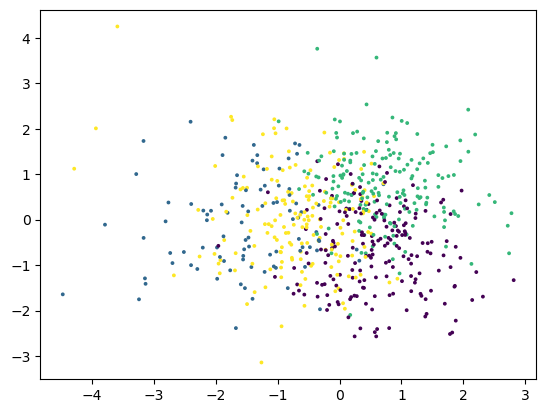

In [635]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, OPTICS, DBSCAN
from sklearn.decomposition import PCA
# clusters = DBSCAN().fit_predict(embedding)
# clusters = OPTICS().fit_predict(embedding)
clusters = KMeans(4).fit_predict(embedding)
plotvals = embedding
if embedding.shape[1] > 2:
    plotvals = PCA(2).fit_transform(embedding)
plt.scatter(plotvals[:,0],plotvals[:,1],s=3,c=clusters)

In [647]:
temp = pd.Series(clusters,rm.index)
temp.name = 'cluster'
temp.to_csv('../data/radiomics_clusters.csv')
pd.read_csv('../data/radiomics_clusters.csv').set_index("id")

,cluster
id,
10001,3
10184,1
10009,3
10010,1
10069,0
...,...
74,3
233,3
165,3


In [637]:
from Preprocessing import DTDataset
from Constants import Const

df = DTDataset().get_data()
df = df[Const.decisions+Const.timeseries_censoring]
df = df.merge(temp,on='id')
df['sequence'] = df[Const.decisions].apply(lambda x: ''.join([str(i) for i in x]),axis=1)
df['outcomes'] = df[Const.timeseries_censoring].apply(lambda x: ''.join([str(i) for i in x]),axis=1)
df.head()

/home/awentze2/git_repos/DigitalTwinVis/python/Preprocessing.py:186: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dummy_df = pd.get_dummies(df[to_onehot].fillna(0).astype(str),drop_first=False)
/home/awentze2/git_repos/DigitalTwinVis/python/Preprocessing.py:292: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  processed_df = preprocess_dt_data(df,self.ln_cols).fillna(0).drop(['DLT_Type'],axis=1)


,Decision 1 (Induction Chemo) Y/N,Decision 2 (CC / RT alone),Decision 3 Neck Dissection (Y/N),"Overall Survival (1=alive, 0=dead)",LRC,DC,cluster,sequence,outcomes
id,,,,,,,,,
3,0,1,0,0,0,1,2,010,001
5,0,1,0,0,1,1,1,010,011
6,0,1,0,0,1,1,2,010,011
7,0,0,0,0,1,1,1,000,011
8,0,0,0,0,1,1,0,000,011


In [638]:
tempdf = pd.get_dummies(df['cluster']).astype('int').merge(df['sequence'],on='id')
tempdf1 = tempdf.groupby('sequence').mean()
tempdf1.columns = ['cluster' + str(c) for c in tempdf1.columns]
tempdf2 = tempdf.groupby('sequence').sum()
tempdf2.columns = ['clustersum' + str(c) for c in tempdf2.columns]
tempdf = tempdf1.merge(tempdf2,on='sequence')
tempdf

,cluster0,cluster1,cluster2,cluster3,clustersum0,clustersum1,clustersum2,clustersum3
sequence,,,,,,,,
000,0.403509,0.157895,0.245614,0.192982,23,9,14,11
001,0.363636,0.000000,0.454545,0.181818,4,0,5,2
010,0.269058,0.161435,0.327354,0.242152,60,36,73,54
011,0.215686,0.176471,0.274510,0.333333,11,9,14,17
100,0.288889,0.244444,0.288889,0.177778,13,11,13,8
101,0.384615,0.153846,0.307692,0.153846,5,2,4,2
110,0.340000,0.120000,0.260000,0.280000,34,12,26,28
111,0.305556,0.083333,0.277778,0.333333,11,3,10,12


In [639]:
tempdfo = pd.get_dummies(df['cluster']).astype('int').merge(df['outcomes'],on='id')
tempdf1o = tempdfo.groupby('outcomes').mean()
tempdf1o.columns = ['cluster' + str(c) for c in tempdf1.columns]
tempdf2o = tempdfo.groupby('outcomes').sum()
tempdf2o.columns = ['clustersum' + str(c) for c in tempdf2.columns]
tempdfo = tempdf1o.merge(tempdf2o,on='outcomes')
tempdfo

,clustercluster0,clustercluster1,clustercluster2,clustercluster3,clustersumclustersum0,clustersumclustersum1,clustersumclustersum2,clustersumclustersum3
outcomes,,,,,,,,
000,0.312500,0.062500,0.437500,0.187500,5,1,7,3
001,0.379310,0.137931,0.241379,0.241379,11,4,7,7
010,0.250000,0.178571,0.357143,0.214286,7,5,10,6
011,0.250000,0.160714,0.303571,0.285714,14,9,17,16
100,1.000000,0.000000,0.000000,0.000000,1,0,0,0
101,0.333333,0.233333,0.200000,0.233333,10,7,6,7
110,0.333333,0.000000,0.416667,0.250000,4,0,5,3
111,0.299451,0.153846,0.293956,0.252747,109,56,107,92


In [640]:
from sklearn.feature_selection import chi2
chi2(pd.get_dummies(df.outcomes),pd.get_dummies(df['cluster']).astype('int'))[1]

array([0.53504753, 0.81293053, 0.83874485, 0.851925  , 0.50695147,
       0.50256673, 0.48220058, 0.99910037])

In [641]:
chi2(df[Const.decisions],pd.get_dummies(df['cluster']).astype('int'))[1]

array([0.82918093, 0.74003295, 0.64110964])

In [642]:
chi2(df[Const.timeseries_censoring],pd.get_dummies(df['cluster']).astype('int'))[1]

array([0.99229362, 0.97593136, 0.95510819])

<Axes: xlabel='sequence'>

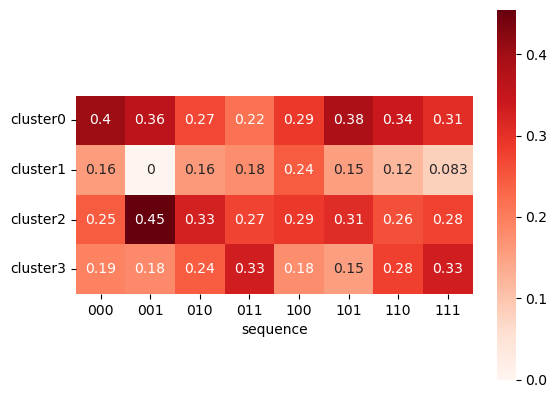

In [643]:
import seaborn as sns

sns.heatmap(tempdf1.T,
              annot=True,
              square=True,
              cmap='Reds')

<Axes: xlabel='outcomes'>

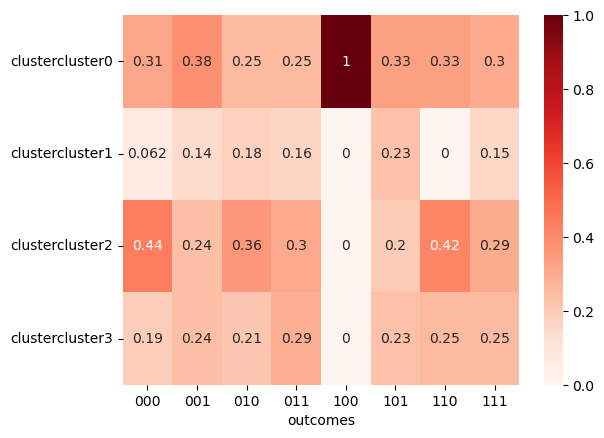

In [644]:
sns.heatmap(tempdf1o.T,
              annot=True,
              cmap='Reds')

Text(0, 0.5, 'cluster %')

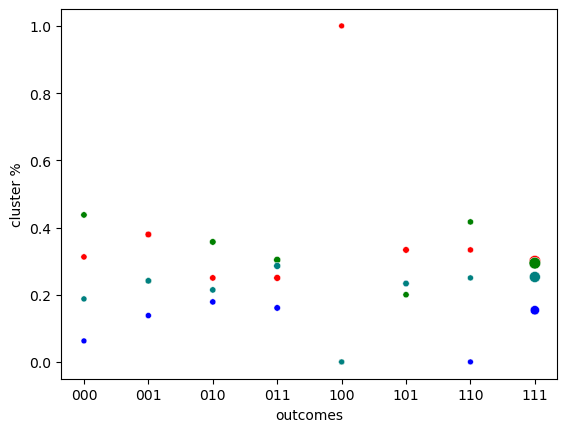

In [645]:
fig,ax=plt.subplots(1,1)
plotstuff = tempdfo.copy()
maxsize = plotstuff[[c for c in plotstuff.columns if 'clustersum' in c]].max().max()
colors=['red','blue','green','teal','pink','purple','grey','black']
i=0
for col1,col2 in zip(tempdf1o.columns,tempdf2o.columns):
    sns.scatterplot(plotstuff,
               x='outcomes',
               y=col1,
                size=col2,
                    color=colors[i],
                    legend=False,
                    ax=ax,
                    size_norm=(1,maxsize)
                   )
    i+=1
ax.set_ylabel('cluster %')

In [534]:
df.groupby('sequence').count()

,Decision 1 (Induction Chemo) Y/N,Decision 2 (CC / RT alone),Decision 3 Neck Dissection (Y/N),cluster
sequence,,,,
000,57,57,57,57
001,11,11,11,11
010,223,223,223,223
011,51,51,51,51
100,45,45,45,45
101,13,13,13,13
110,100,100,100,100
111,36,36,36,36
